# Expolrotary data analysis

## Import libraries

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot

## Load Data

In [24]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

## Data merging

In [25]:
df = sales_train.merge(items, on='item_id', how='left')
df = df.merge(item_categories, on='item_category_id', how='left')
df = df.merge(shops, on='shop_id', how='left')

## Modeling target variables distributions

### Distribution of monthly item counts by date block number

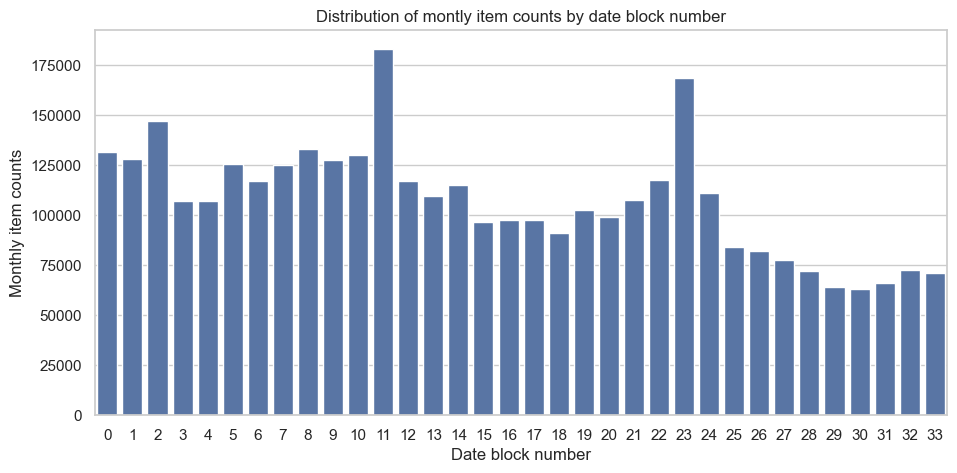

In [26]:
mpl.rc("font", size = 13)
figure, ax = plt.subplots()
figure.set_size_inches(11, 5)

group_month_sum = df.groupby("date_block_num").agg({"item_cnt_day": "sum"}).reset_index()

sns.barplot(x = "date_block_num", y = "item_cnt_day", data = group_month_sum)
ax.set(title = "Distribution of montly item counts by date block number",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");

### Distribution of total item counts by category id 

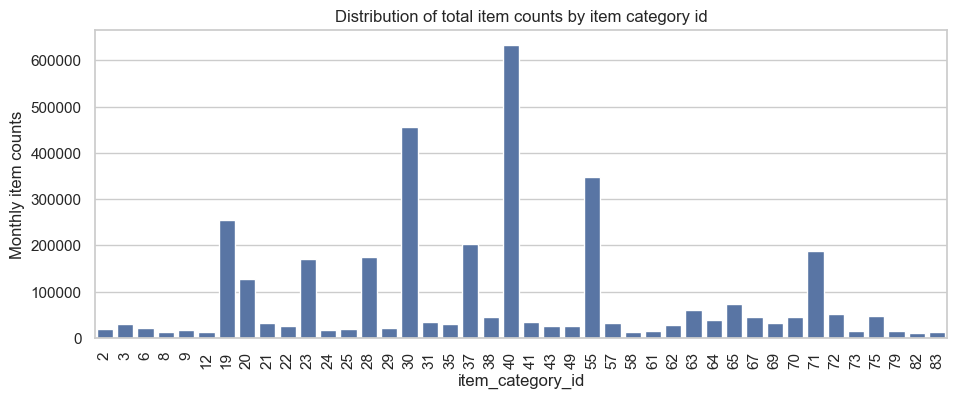

In [27]:
figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

group_cat_sum = df.groupby("item_category_id").agg({"item_cnt_day": "sum"}).reset_index()
group_cat_sum = group_cat_sum[group_cat_sum["item_cnt_day"] > 10000]

sns.barplot(x = "item_category_id", y = "item_cnt_day", data = group_cat_sum)
ax.set(title = "Distribution of total item counts by item category id",
       xlabel = "item_category_id",
       ylabel = "Monthly item counts");
ax.tick_params(axis = "x", labelrotation = 90)

### Checked the most expensive categories

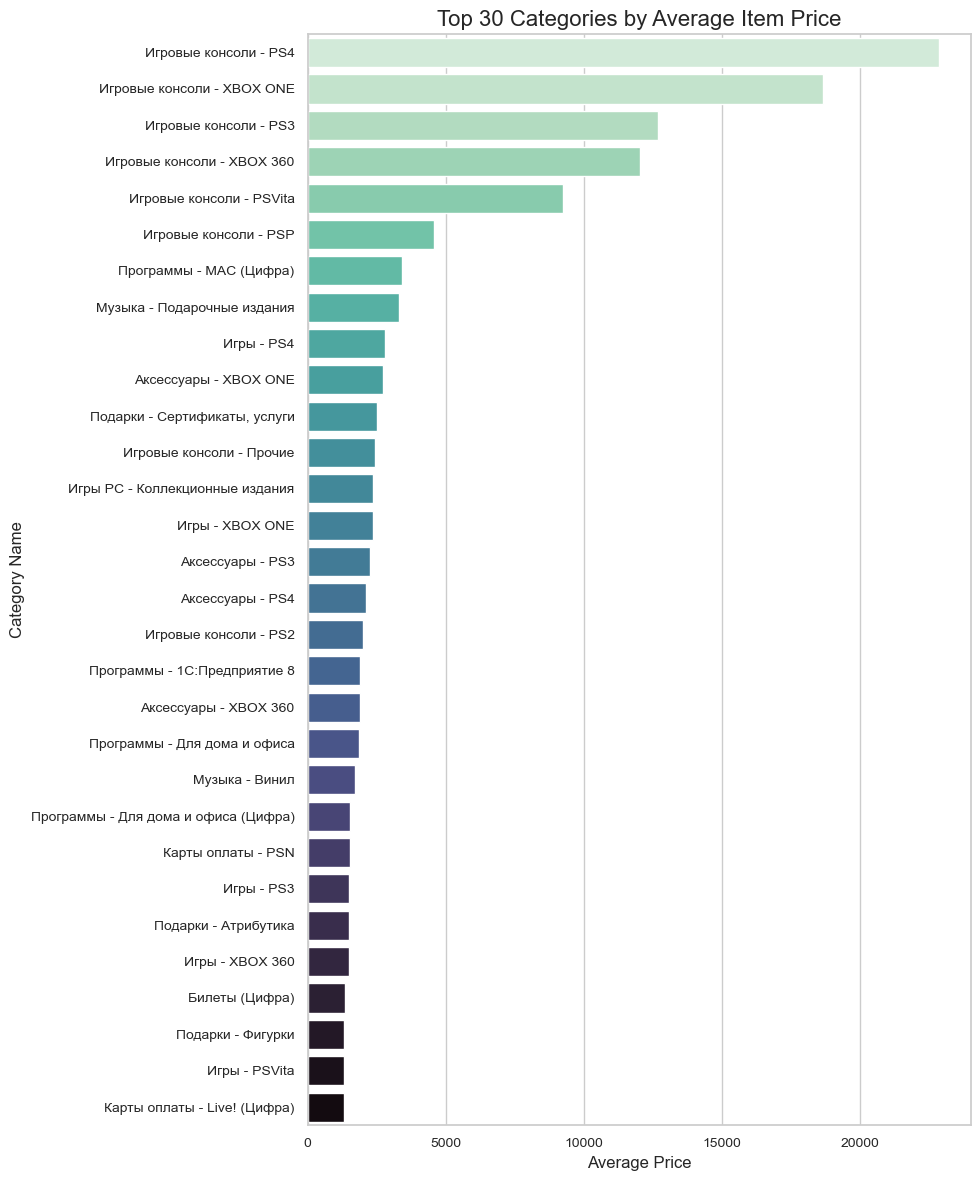

In [28]:
avg_price = df.groupby("item_category_name")["item_price"].mean().sort_values(ascending=False).head(30)
plt.figure(figsize=(10, 12))
sns.barplot(x=avg_price.values, y=avg_price.index, hue=avg_price.index, palette="mako_r", legend=False)
plt.title("Top 30 Categories by Average Item Price", fontsize=16)
plt.xlabel("Average Price", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

We can see that the consoles is the most expensive category, but is it the most valuable to sale?

### Check the best selling products

In [64]:
most_popular = df.groupby("item_id")["item_cnt_day"].sum().sort_values(ascending=False)

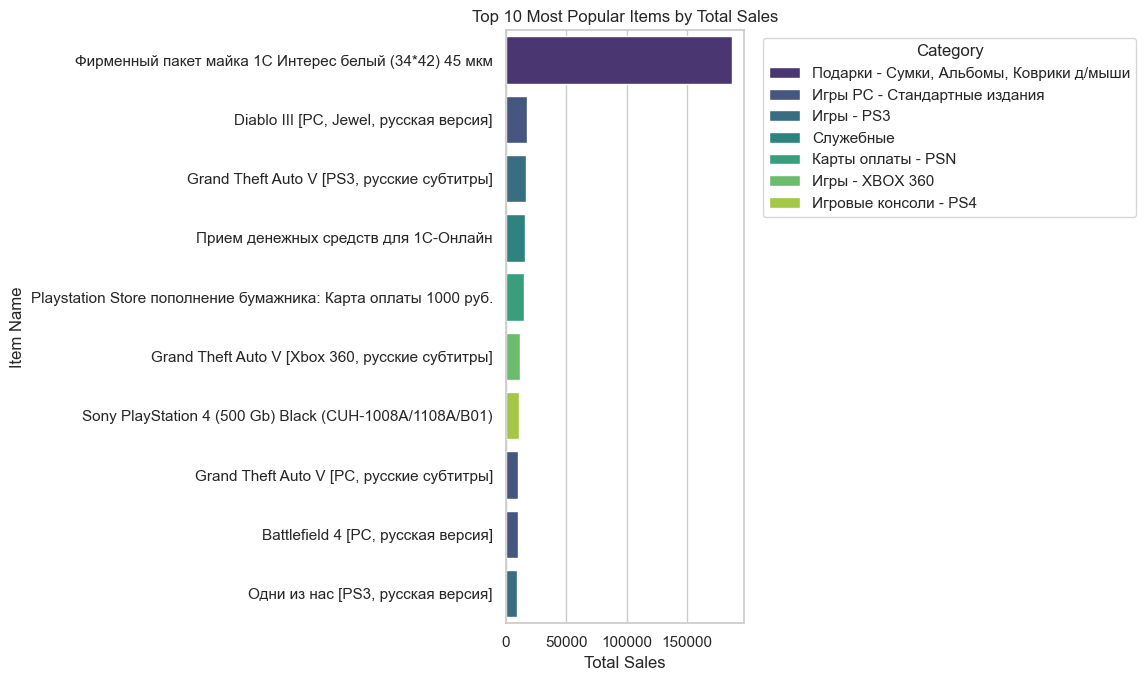

In [66]:
top_10 = most_popular.head(10).reset_index()
top_10 = top_10.merge(items[['item_id', 'item_name', 'item_category_id']], on='item_id', how='left')

top_10 = top_10.merge(item_categories[['item_category_id', 'item_category_name']], on='item_category_id', how='left')

plt.figure(figsize=(12,7))
sns.barplot(x='item_cnt_day', y='item_name', data=top_10,
            palette="viridis", hue='item_category_name')

plt.title("Top 10 Most Popular Items by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item Name")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда справа
plt.tight_layout()
plt.show()

Best and worst shops/items

C:\Users\SUPER\AppData\Local\Temp\ipykernel_23672\3287022074.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[0, 0], data=top_items, x='item_name', y='item_cnt_day', palette='Blues_r')
C:\Users\SUPER\AppData\Local\Temp\ipykernel_23672\3287022074.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[0, 1], data=top_shops, x='shop_name', y='item_cnt_day', palette='Greens_r')
C:\Users\SUPER\AppData\Local\Temp\ipykernel_23672\3287022074.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axs[1, 0], data=bottom_shops, x='shop

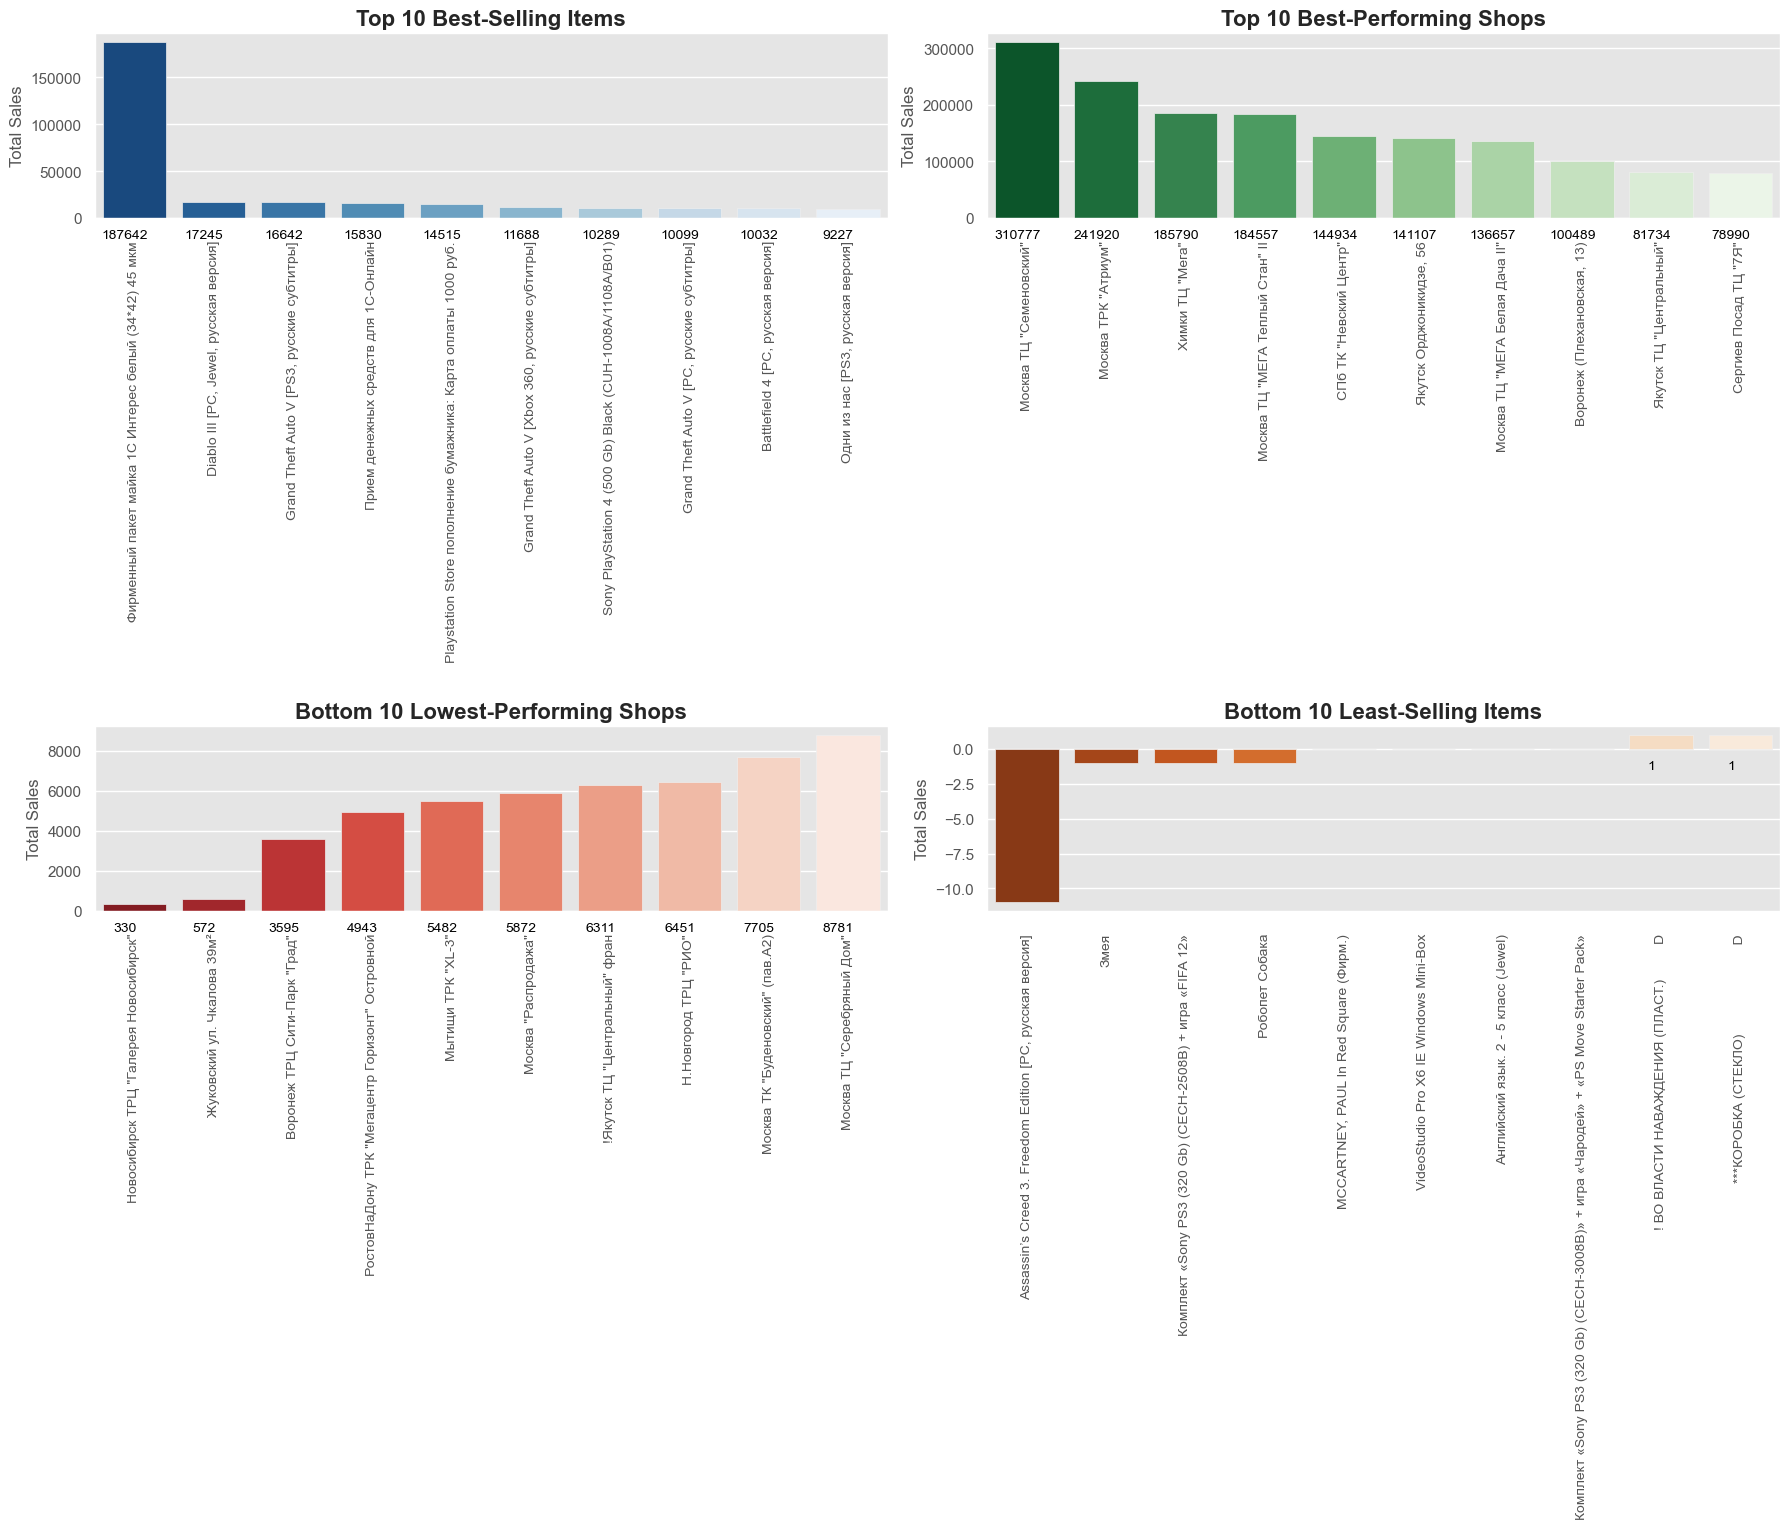

In [111]:
item_sales = df.groupby(['item_id', 'item_name'])['item_cnt_day'].sum().reset_index()
shop_sales = df.groupby(['shop_id', 'shop_name'])['item_cnt_day'].sum().reset_index()

top_items = item_sales.nlargest(10, 'item_cnt_day')
bottom_items = item_sales.nsmallest(10, 'item_cnt_day')
top_shops = shop_sales.nlargest(10, 'item_cnt_day')
bottom_shops = shop_sales.nsmallest(10, 'item_cnt_day')

def annotate_bars_below_left(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x = p.get_x() + p.get_width() * 0.35
            ax.annotate(f'{int(height)}',
                        (x, 0),
                        ha='center', va='top',
                        fontsize=10,
                        color='black',
                        xytext=(0, -8),
                        textcoords='offset points')

plt.style.use('ggplot')

fig, axs = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(ax=axs[0, 0], data=top_items, x='item_name', y='item_cnt_day', palette='Blues_r')
axs[0, 0].set_title('Top 10 Best-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 0])

sns.barplot(ax=axs[0, 1], data=top_shops, x='shop_name', y='item_cnt_day', palette='Greens_r')
axs[0, 1].set_title('Top 10 Best-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 1])

sns.barplot(ax=axs[1, 0], data=bottom_shops, x='shop_name', y='item_cnt_day', palette='Reds_r')
axs[1, 0].set_title('Bottom 10 Lowest-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 0])

sns.barplot(ax=axs[1, 1], data=bottom_items, x='item_name', y='item_cnt_day', palette='Oranges_r')
axs[1, 1].set_title('Bottom 10 Least-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 1])

for ax in axs.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('Total Sales', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=10)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=2)

for ax in axs[1, :]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.1, pos.width, pos.height])

plt.show()

## Detect trends, seasonality, and cycles

In [68]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('month')['item_cnt_day'].sum().to_timestamp()

### Monthly total sales over time

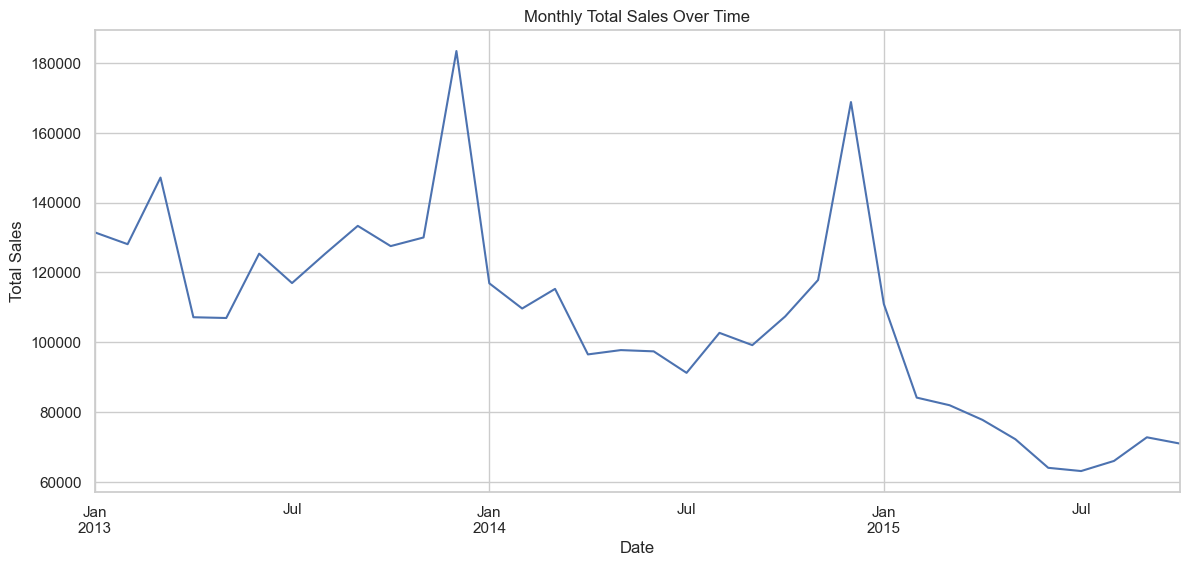

In [72]:
plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Seasonal Decomposition of Sales

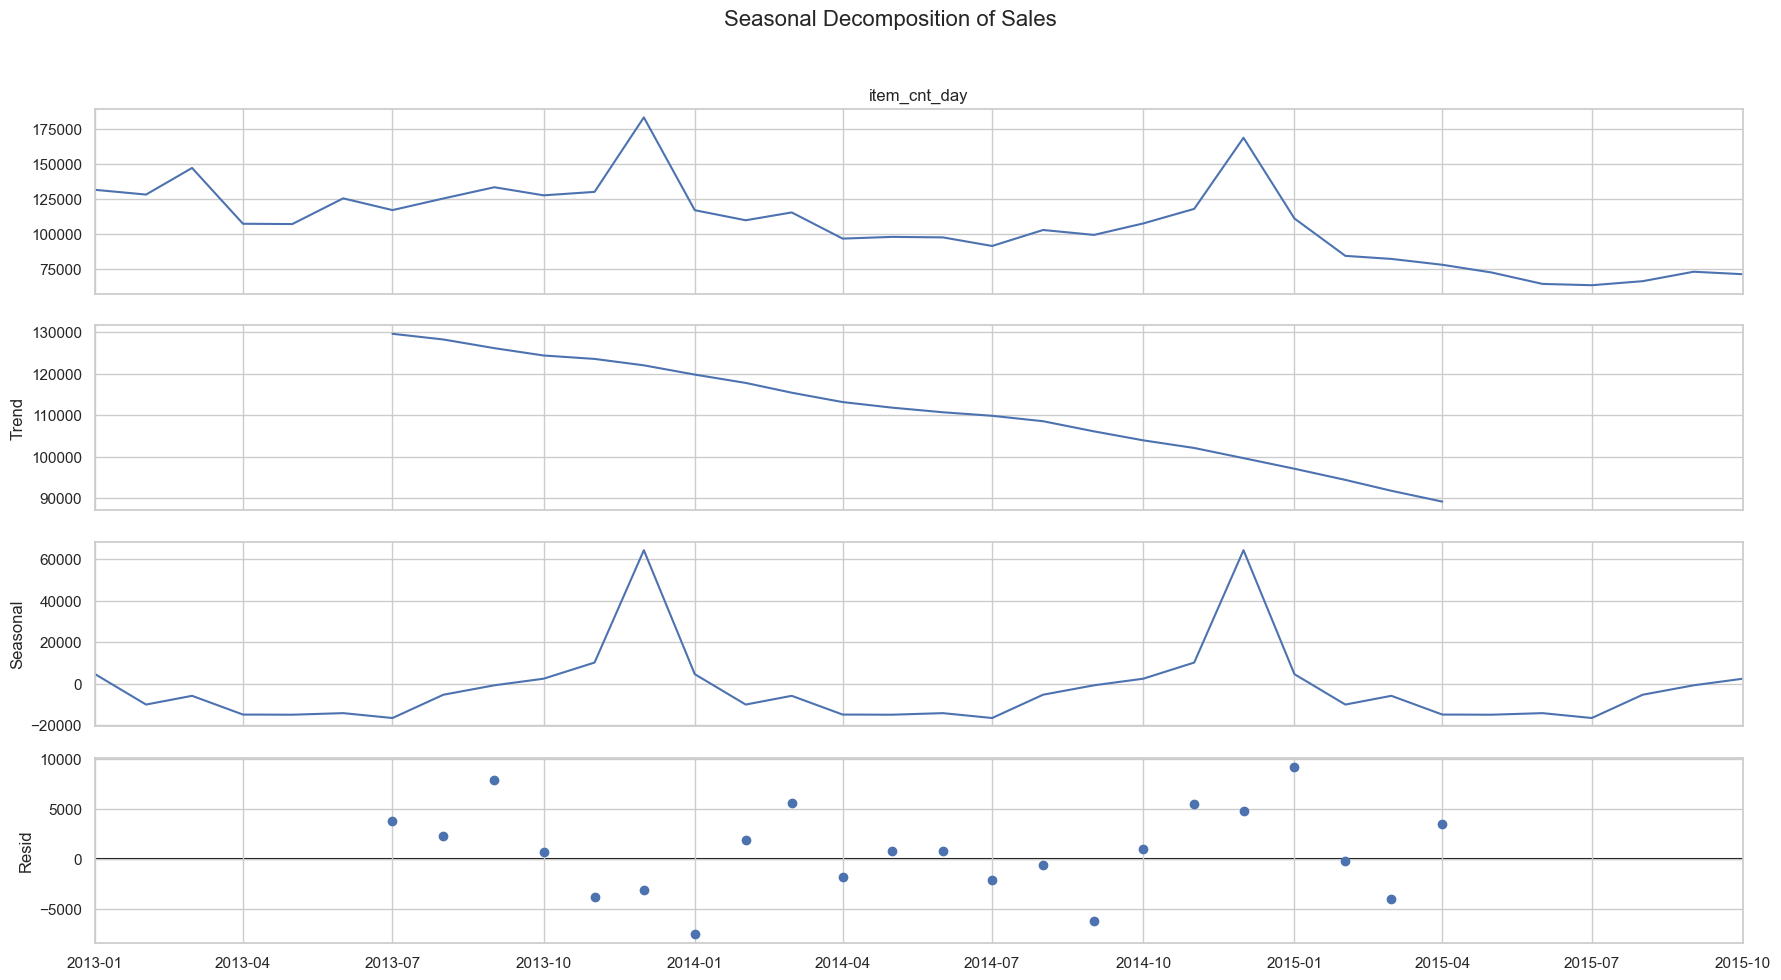

In [79]:
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(18, 10)  
fig.suptitle("Seasonal Decomposition of Sales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

### Autocorrelation of Monthly Sales

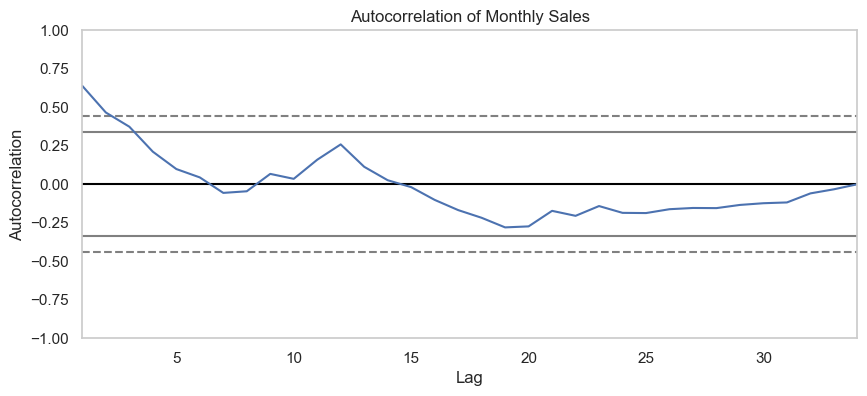

In [75]:
plt.figure(figsize=(10,4))
autocorrelation_plot(monthly_sales)
plt.title("Autocorrelation of Monthly Sales")
plt.show()

### Sales with 3 month Moving Average

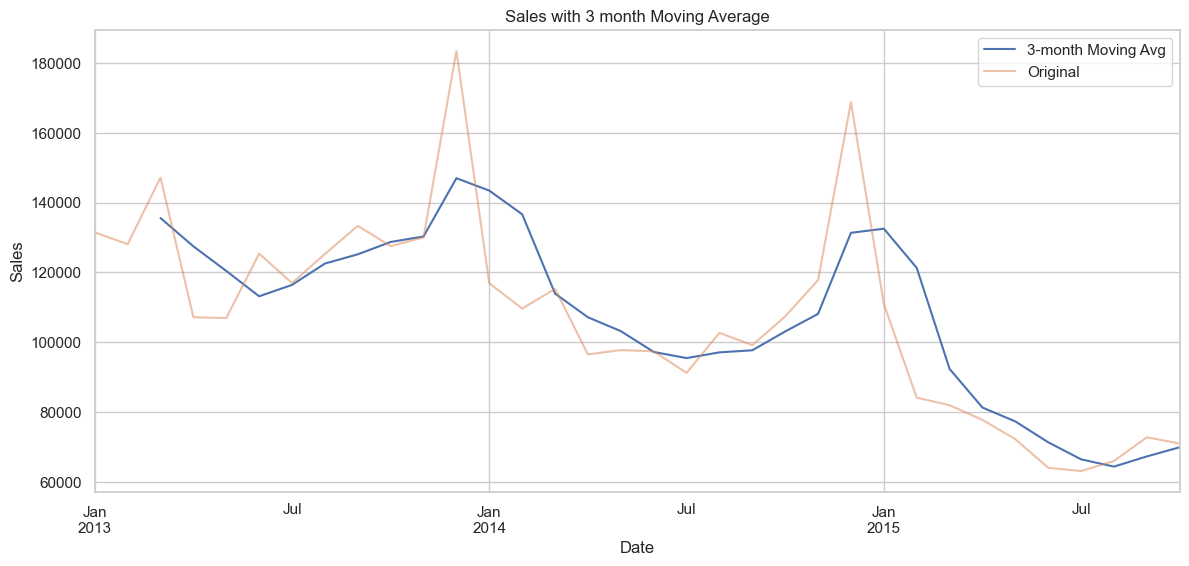

In [80]:
monthly_sales.rolling(window=3).mean().plot(figsize=(14,6), label='3-month Moving Avg')
monthly_sales.plot(alpha=0.5, label='Original')
plt.legend()
plt.title("Sales with 3 month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Shop-level and item-level sales behavior

C:\Users\SUPER\AppData\Local\Temp\ipykernel_23672\2904007000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shop_sales.values, y=shop_sales.index, palette='mako')


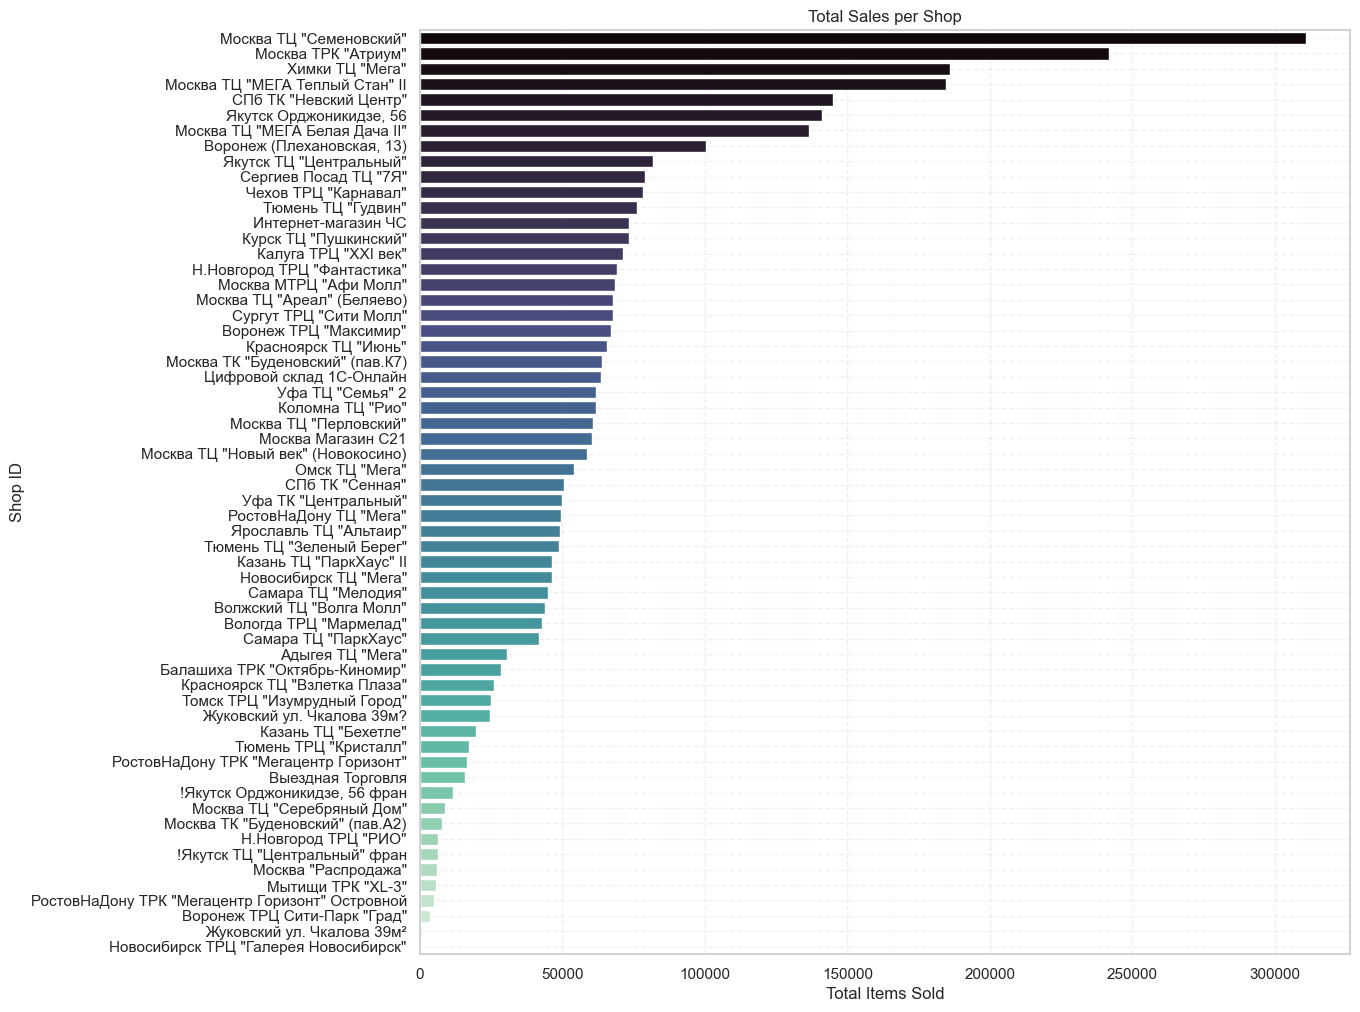

In [90]:
shop_sales = df.groupby('shop_name')['item_cnt_day'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,12))
sns.barplot(x=shop_sales.values, y=shop_sales.index, palette='mako')
plt.title("Total Sales per Shop")
plt.xlabel("Total Items Sold")
plt.ylabel("Shop ID")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()